Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values count
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin        

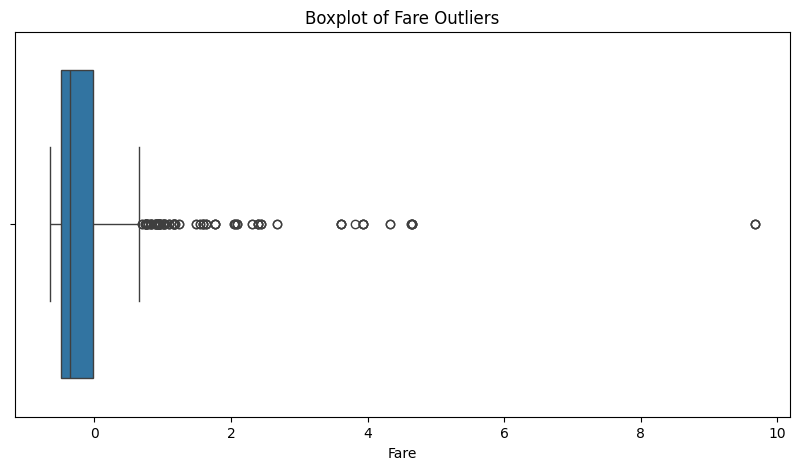

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

url = "Titanic-Dataset.csv"
df = pd.read_csv(url)

print("Dataset info:")
print(df.info())

print("\nMissing values count")
print(df.isnull().sum())

df.drop(columns=['Cabin'], inplace=True)

df['Age'] = df["Age"].fillna(df["Age"].median())

df['Embarked'] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("\n\n After Cleaning")
print(df.isnull().sum())

df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

df['Sex'] = df["Sex"].map({"male":1, "female":0})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("\n", df.head())

scaler = StandardScaler()
columns_to_scale = ['Age', 'Fare']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("\nAfter Standardization")
print(df[['Age', 'Fare']].head())

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Fare'])

plt.title("Boxplot of Fare Outliers")
plt.show()